In [1]:
from ovo import db, schedulers, storage, descriptors, descriptors_refolding, design_logic, descriptor_logic, project_logic
from ovo import models_rfdiffusion, Threshold
import os
import time
import itertools

Registering plugin ovo_promb
Registering plugin ovo_proteindj


OVO home /home/username/ovo

In [2]:
project, project_round = project_logic.get_or_create_project_round("OVO Publication Examples 1", "Motif scaffolding")

In [3]:
contigs = []
for a, b, c in itertools.permutations(['A56-56', 'A100-100', 'A125-125']):
    contig = f'10-100/{a}/10-100/{b}/10-100/{c}/10-100'
    print(contig)
    contigs.append(contig)

10-100/A56-56/10-100/A100-100/10-100/A125-125/10-100
10-100/A56-56/10-100/A125-125/10-100/A100-100/10-100
10-100/A100-100/10-100/A56-56/10-100/A125-125/10-100
10-100/A100-100/10-100/A125-125/10-100/A56-56/10-100
10-100/A125-125/10-100/A56-56/10-100/A100-100/10-100
10-100/A125-125/10-100/A100-100/10-100/A56-56/10-100


In [4]:
POOL_NAME = '1A41 6*100*8 designs active site weights'
POOL_DESCRIPTION = 'length 150 with 10-100 residues spacing the active site residues'

workflow = models_rfdiffusion.RFdiffusionScaffoldDesignWorkflow(
    rfdiffusion_params=models_rfdiffusion.RFdiffusionParams(
        input_pdb_paths=[storage.store_input(project.id, '../../data/inputs/1A4I.pdb')],
        contigs=contigs,
        num_designs=100,
        contigmap_length=150,
        model_weights='ActiveSite',
        batch_size=50,
    ),
    protein_mpnn_params=models_rfdiffusion.ProteinMPNNParams(
        num_sequences=8,
        sampling_temp=0.1
    ),
    refolding_params=models_rfdiffusion.RefoldingParams(
        primary_test="af2_model_1_ptm_ft_3rec",
    )
)
workflow.validate()
workflow.get_table_row()

Workflow     input                                                                 None
             type                                           RFdiffusion scaffold design
RFdiffusion  contigs                  [10-100/A56-56/10-100/A100-100/10-100/A125-125...
             hotspots                                                              None
             model_weights                                                   ActiveSite
             timesteps                                                               50
             partial_diffusion                                                    False
             num_designs                                                            100
             cyclic_offset                                                        False
             batch_size                                                              50
             contigmap_length                                                       150
             inpaint_seq        

## Select project and submit workflow

In [5]:
print(schedulers.keys())

SCHEDULER_KEY = 'pbs_singularity'

dict_keys(['slurm_singularity', 'pbs_singularity', 'local_singularity', 'local_conda', 'local_single_gpu'])


In [6]:
design_job, pool = design_logic.submit_design_workflow(
    workflow=workflow,
    pool_name=POOL_NAME,
    pool_description=POOL_DESCRIPTION,
    scheduler_key=SCHEDULER_KEY,
    round_id=project_round.id,
)

Submitting workflow: nextflow run -with-trace trace.txt -work-dir /home/username/ovo/workdir/work /home/username/projects/ovo-open-source/ovo/ovo/pipelines/rfdiffusion-end-to-end --publish_dir output --reference_files_dir /home/username/ovo/reference_files --shared_modules ovo:/home/username/projects/ovo-open-source/ovo/ovo,ovo_promb:/home/username/projects/ovo-open-source/ovo-promb/ovo_promb,ovo_proteindj:/home/username/projects/ovo-proteindj/ovo_proteindj -config /home/username/projects/ovo-open-source/ovo/ovo/pipelines/nextflow_default.config -config /home/username/projects/ovo-open-source/ovo/ovo/pipelines/rfdiffusion-end-to-end/nextflow.config -profile singularity -config /home/username/ovo/nextflow_pbs_singularity.config -ansi-log false -bg --batch_size 50 --rfdiffusion_input_pdb /home/username/ovo/workdir/inputs/f9/cbb03ea7dae1b6b46555ab2c9c3be83067e4ca/1A4I.pdb --rfdiffusion_num_designs 100 --rfdiffusion_contig 10-100/A56-56/10-100/A100-100/10-100/A125-125/10-100,10-100/A56-56/

In [7]:
print(pool.id)

ogc


### Status of current job

In [9]:
design_logic.get_design_jobs_table(id=pool.id)

Pool  \
                                                name   
(Pool, id)                                             
ogc         1A41 6*100*8 designs active site weights   

                                                                    Job  \
                                                  description    status   
(Pool, id)                                                                
ogc         length 150 with 10-100 residues spacing the ac...  ⏳Running   

                                         Designs       Workflow  \
               duration         created accepted total    input   
(Pool, id)                                                        
ogc         00d:00h:13m  13 minutes ago     None  None     None   

                                         \
                                   type   
(Pool, id)                                
ogc         RFdiffusion scaffold design   

                                                  RFdiffusion  ...  \
                                                      contigs  ...   
(Pool, id)                                                     ...   
ogc         [10-100/A56-56/10-100/A100-100/10-100/A125-125...  ...   

                    ProteinMPNN                                               \
           num_sequence_designs omit_aa sampling_temp bias_aa run_parameters   
(Pool, id)                                                                     
ogc                           8      CX           0.1                          

                          Refolding              Thresholds                  \
                       primary_test esmfold_fp16    AF2 PAE AF2 Design RMSD   
(Pool, id)                                                                    
ogc         af2_model_1_ptm_ft_3rec        False   ≤ 10.000         ≤ 5.000   

                                  
           AF2 Native Motif RMSD  
(Pool, id)                        
ogc                      ≤ 3.000  

[1 rows x 31 columns]

## Process job results

Save Design and DescriptorValue objects to database, copy PDB files from workdir into OVO storage.

In [11]:
# IMPORTANT
# This will "process" the workflow results, which means they will be copied/downloaded from the nextflow working directory
# to the OVO storage directory, and corresponding Design and DescriptorValue objects will be stored in the DB, pointing to the files.

pool = design_logic.process_results(design_job)

Waiting for job 0d94a286-c078-11f0-85b6-029f0fc8e1cf to finish...
Job finished, processing pool results...


In [12]:
db.Design.count(pool_id=pool.id)

4800

## Visualize designs and AF2 descriptors

In [7]:
import seaborn as sns
from matplotlib import pyplot as plt

%config InlineBackend.figure_format = 'retina'

In [8]:
thresholds = {
    descriptors_refolding.AF2_PRIMARY_PAE.key: Threshold(max_value=5.0),
    descriptors_refolding.AF2_PRIMARY_DESIGN_RMSD.key: Threshold(max_value=2.0),
    descriptors_refolding.AF2_PRIMARY_NATIVE_MOTIF_RMSD.key: Threshold(max_value=1.5),       
    descriptors_refolding.AF2_PRIMARY_PLDDT.key: Threshold(min_value=80),
}

In [9]:
values = descriptor_logic.get_wide_descriptor_table(
    design_ids=db.Design.select_values('id', pool_id=pool.id),
    # only select some selected descriptors to save memory
    # you can remove this argument to fetch all available descriptors
    descriptor_keys=thresholds.keys()
)
values.head()

,Sequence A,AF2 PAE,AF2 Design RMSD,AF2 Native Motif RMSD,AF2 pLDDT
design_id,,,,,
ovo_ogc_01_001_seq01,KEEEELTARLLKYLPWLAKVIIFPKPVSAEEKLKIVIAALEELRKK...,13.825833,6.804540,2.078366,52.052617
ovo_ogc_01_001_seq02,EKEEELRKAILEYLPDVADVLILPEPVSAEEKIKIVAKAMKELEKK...,4.360656,1.014978,1.502979,89.238805
ovo_ogc_01_001_seq03,EEEAELTAAIKEYLPEVAAVLILPKPVSAEEKMKIVVEKLKELRKK...,5.291050,1.137538,1.759953,87.044084
ovo_ogc_01_001_seq04,EREAELRAALLEYLPELADVLILPKPVSAEEKIKIVVERMKELRKK...,11.282478,7.563109,4.282044,63.461554
ovo_ogc_01_001_seq05,EEEAALRAALLAHWPELAEVLIFPRPVSAEEKMEIVVAALERLRAR...,3.529473,0.799206,1.579931,92.151660


In [10]:
designs = db.Design.select_dataframe(
    pool_id=pool.id,
    limit=None,
    # accepted=True, select all designs or accepted designs using this flag
)
print(f'{len(designs):,} total designs')
designs = designs.join(values)
designs.head()

4,800 total designs


,pool_id,structure_path,structure_descriptor_key,accepted,spec,contig_index,Sequence A,AF2 PAE,AF2 Design RMSD,AF2 Native Motif RMSD,AF2 pLDDT
id,,,,,,,,,,,
ovo_ogc_01_001_seq01,ogc,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|ligandmpnn|sequence_structure_path,False,"DesignSpec(chains=[DesignChain(type='protein',...",0,KEEEELTARLLKYLPWLAKVIIFPKPVSAEEKLKIVIAALEELRKK...,13.825833,6.804540,2.078366,52.052617
ovo_ogc_01_001_seq02,ogc,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|ligandmpnn|sequence_structure_path,False,"DesignSpec(chains=[DesignChain(type='protein',...",0,EKEEELRKAILEYLPDVADVLILPEPVSAEEKIKIVAKAMKELEKK...,4.360656,1.014978,1.502979,89.238805
ovo_ogc_01_001_seq03,ogc,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|ligandmpnn|sequence_structure_path,False,"DesignSpec(chains=[DesignChain(type='protein',...",0,EEEAELTAAIKEYLPEVAAVLILPKPVSAEEKMKIVVEKLKELRKK...,5.291050,1.137538,1.759953,87.044084
ovo_ogc_01_001_seq04,ogc,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|ligandmpnn|sequence_structure_path,False,"DesignSpec(chains=[DesignChain(type='protein',...",0,EREAELRAALLEYLPELADVLILPKPVSAEEKIKIVVERMKELRKK...,11.282478,7.563109,4.282044,63.461554
ovo_ogc_01_001_seq05,ogc,project/b8e657bb-b0b0-423e-9235-383a6d8f74e5/p...,rfd_ee|ligandmpnn|sequence_structure_path,False,"DesignSpec(chains=[DesignChain(type='protein',...",0,EEEAALRAALLAHWPELAEVLIFPRPVSAEEKMEIVVAALERLRAR...,3.529473,0.799206,1.579931,92.151660


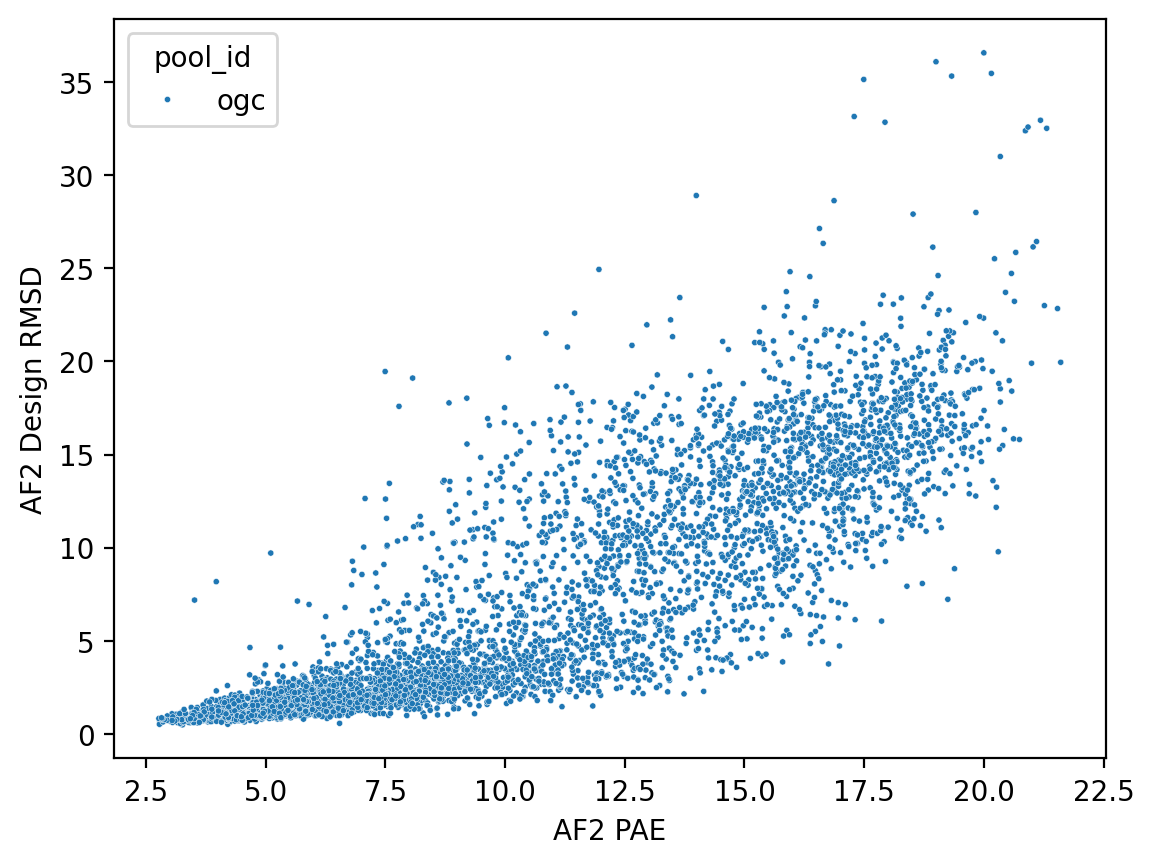

In [11]:
sns.scatterplot(designs, y='AF2 Design RMSD', x='AF2 PAE', hue='pool_id', s=5);

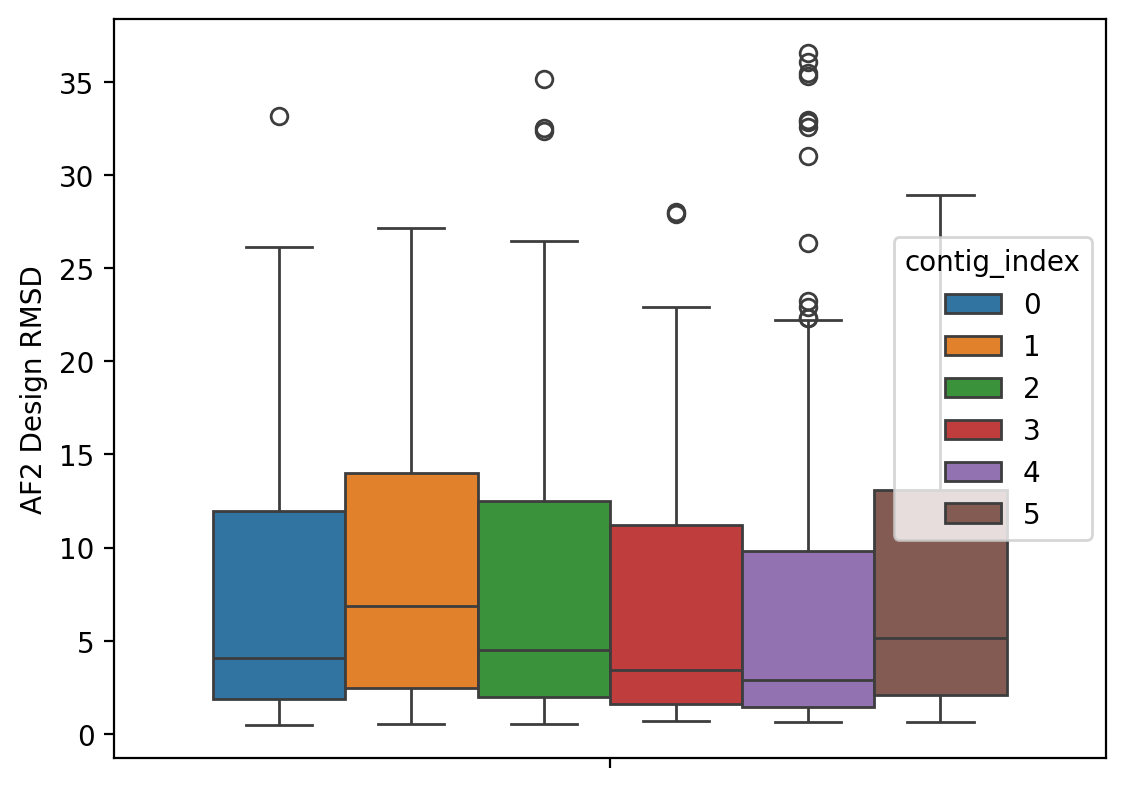

In [12]:
sns.boxplot(designs, y='AF2 Design RMSD', hue='contig_index', palette='tab10');

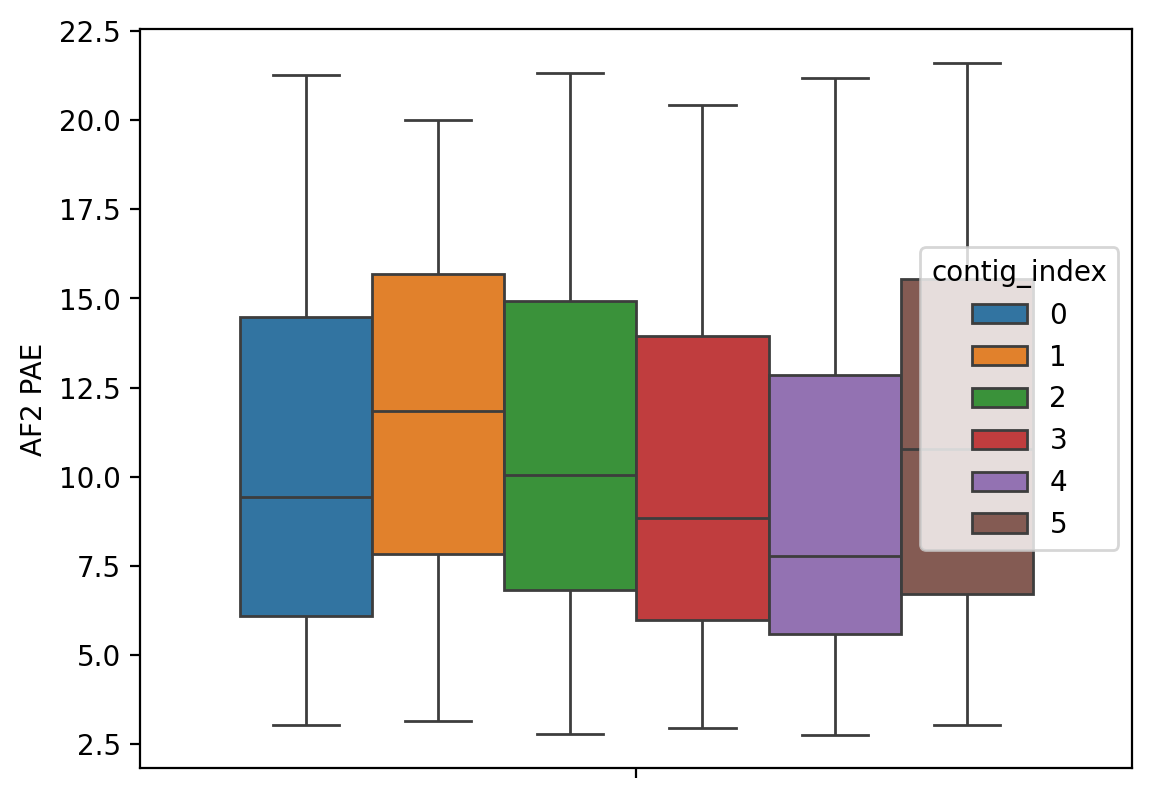

In [13]:
sns.boxplot(designs, y='AF2 PAE', hue='contig_index', palette='tab10');

/home/username/.conda/envs/ovo/lib/python3.13/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 'lw'
  cset = contour_func(


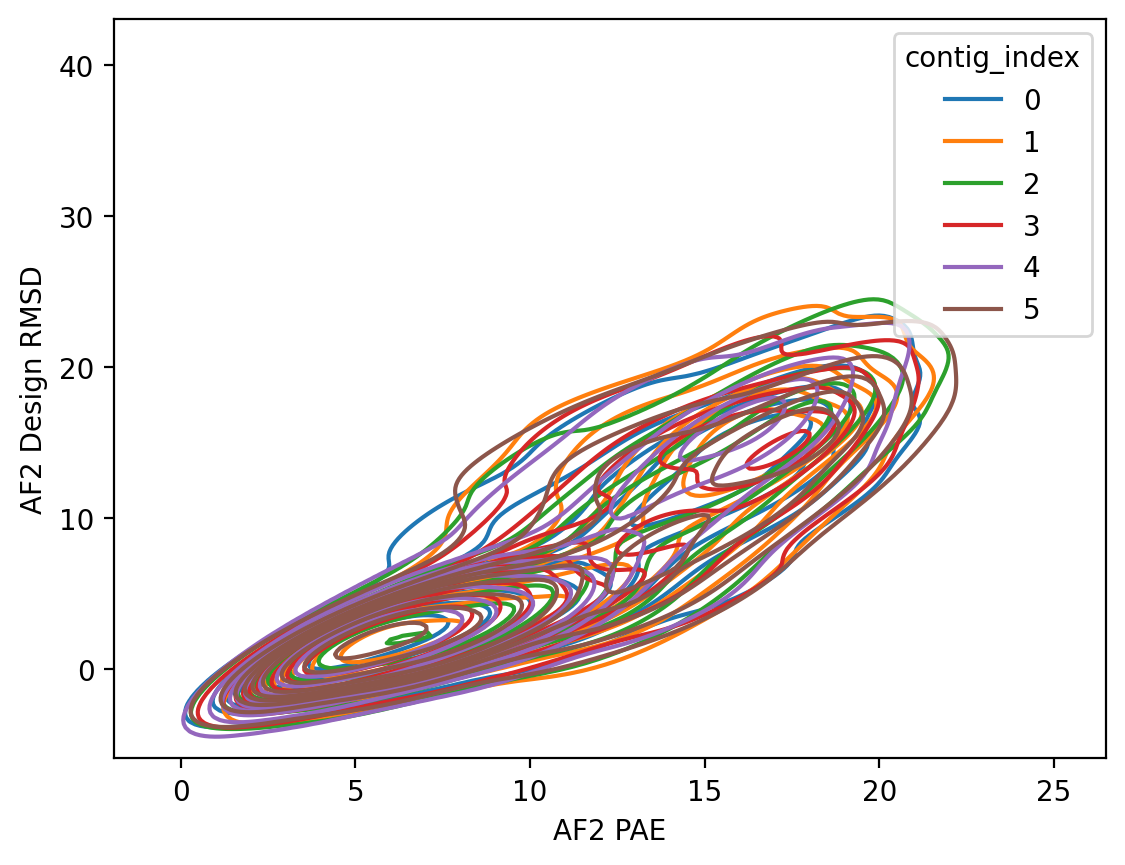

In [14]:
sns.kdeplot(designs, y='AF2 Design RMSD', x='AF2 PAE', hue='contig_index', palette='tab10', lw=1);

In [15]:
def plot_matrix(designs, thresholds, hue='pool_id', **kwargs):
    enabled_thresholds = [(k, t) for k, t in thresholds.items() if t.enabled]
    column_keys = [k for k, t in enabled_thresholds]
    column_descriptors = [descriptors.ALL_DESCRIPTORS_BY_KEY[k] for k in column_keys]
    column_names = [d.name for d in column_descriptors]
    g = sns.pairplot(designs[column_names + ['pool_id']], hue=hue, plot_kws=dict(s=5), diag_kind='hist', **kwargs);
    for i, (yd, (_, yt)) in enumerate(zip(column_descriptors, enabled_thresholds)):
        for j, (xd, (_, xt)) in enumerate(zip(column_descriptors, enabled_thresholds)):
            xbounds = xt.get_bounds(xd, designs[xd.name])
            ybounds = yt.get_bounds(yd, designs[yd.name])
            ax = g.axes[i][j]
            if i == j:
                ax.axvspan(*xbounds, alpha=0.2, color='#00ff00')
                continue
            assert ax.get_xlabel() == xd.name, f"{ax.get_xlabel()} != {xd.name}"
            assert ax.get_ylabel() == yd.name, f"{ax.get_ylabel()} != {yd.name}"
            ax.add_patch(plt.Rectangle((xbounds[0], ybounds[0]), xbounds[1]-xbounds[0], ybounds[1]-ybounds[0], alpha=0.2, color='#00ff00'))

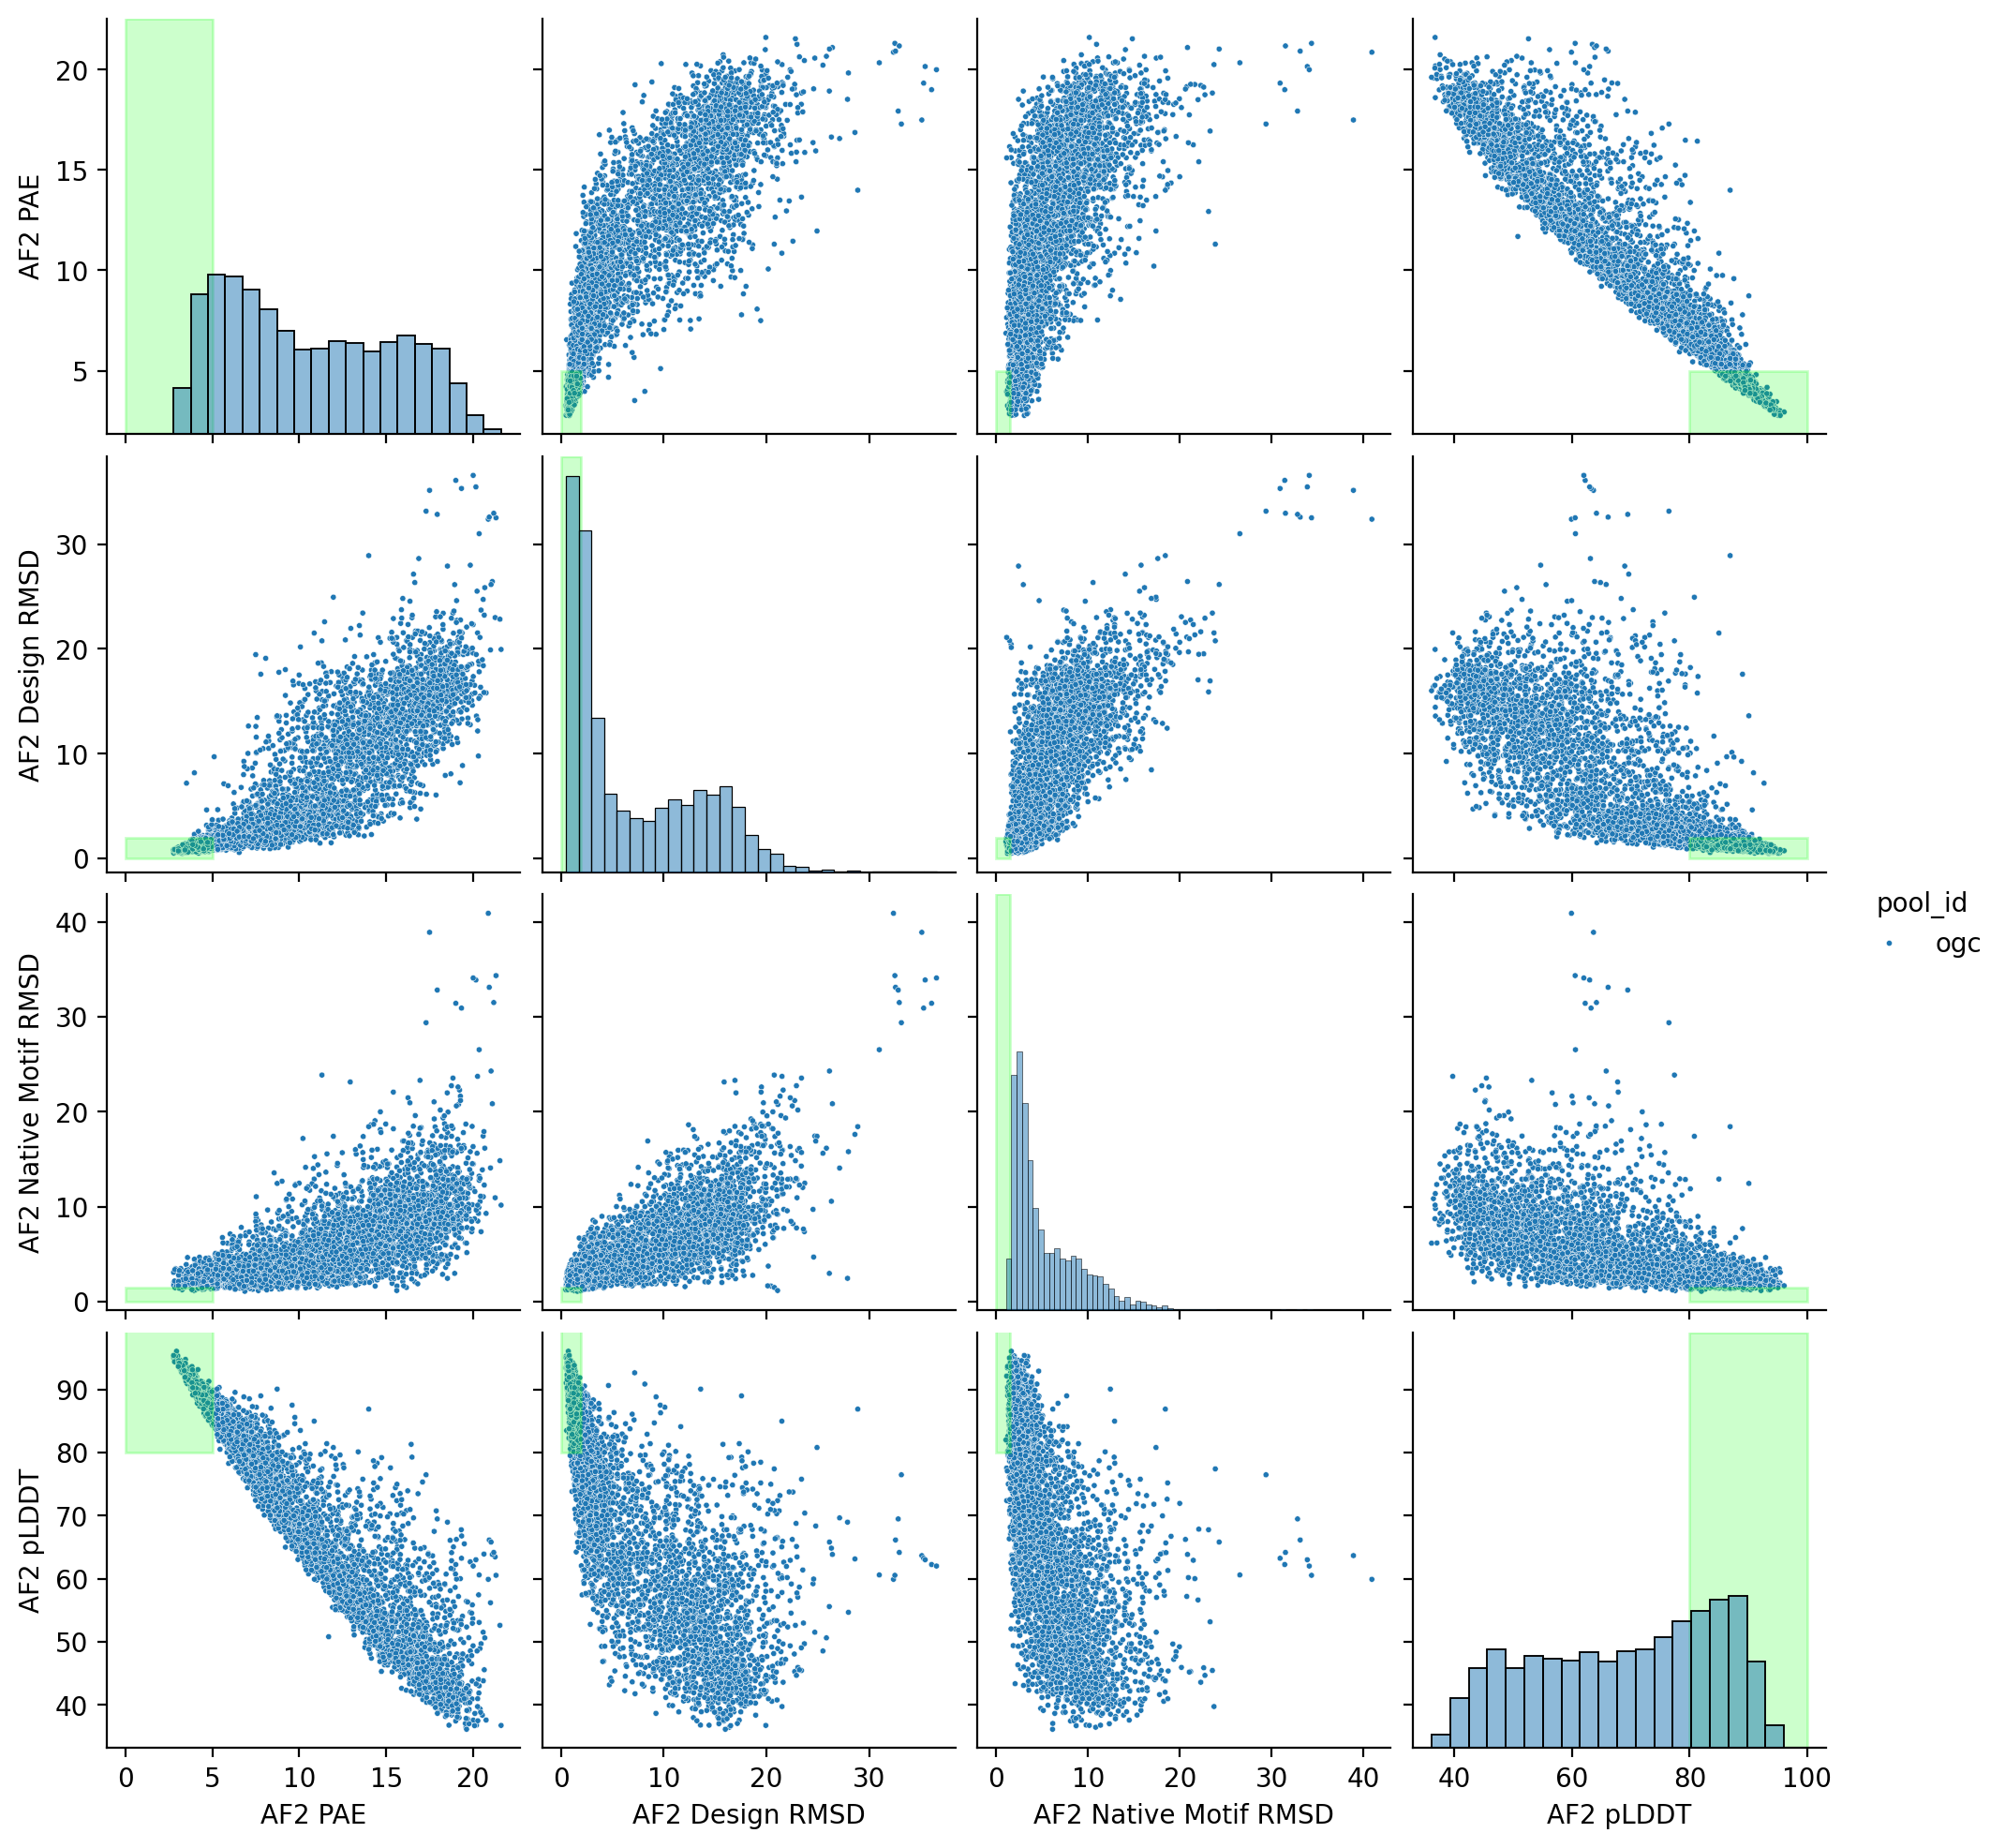

In [16]:
plot_matrix(designs, thresholds)

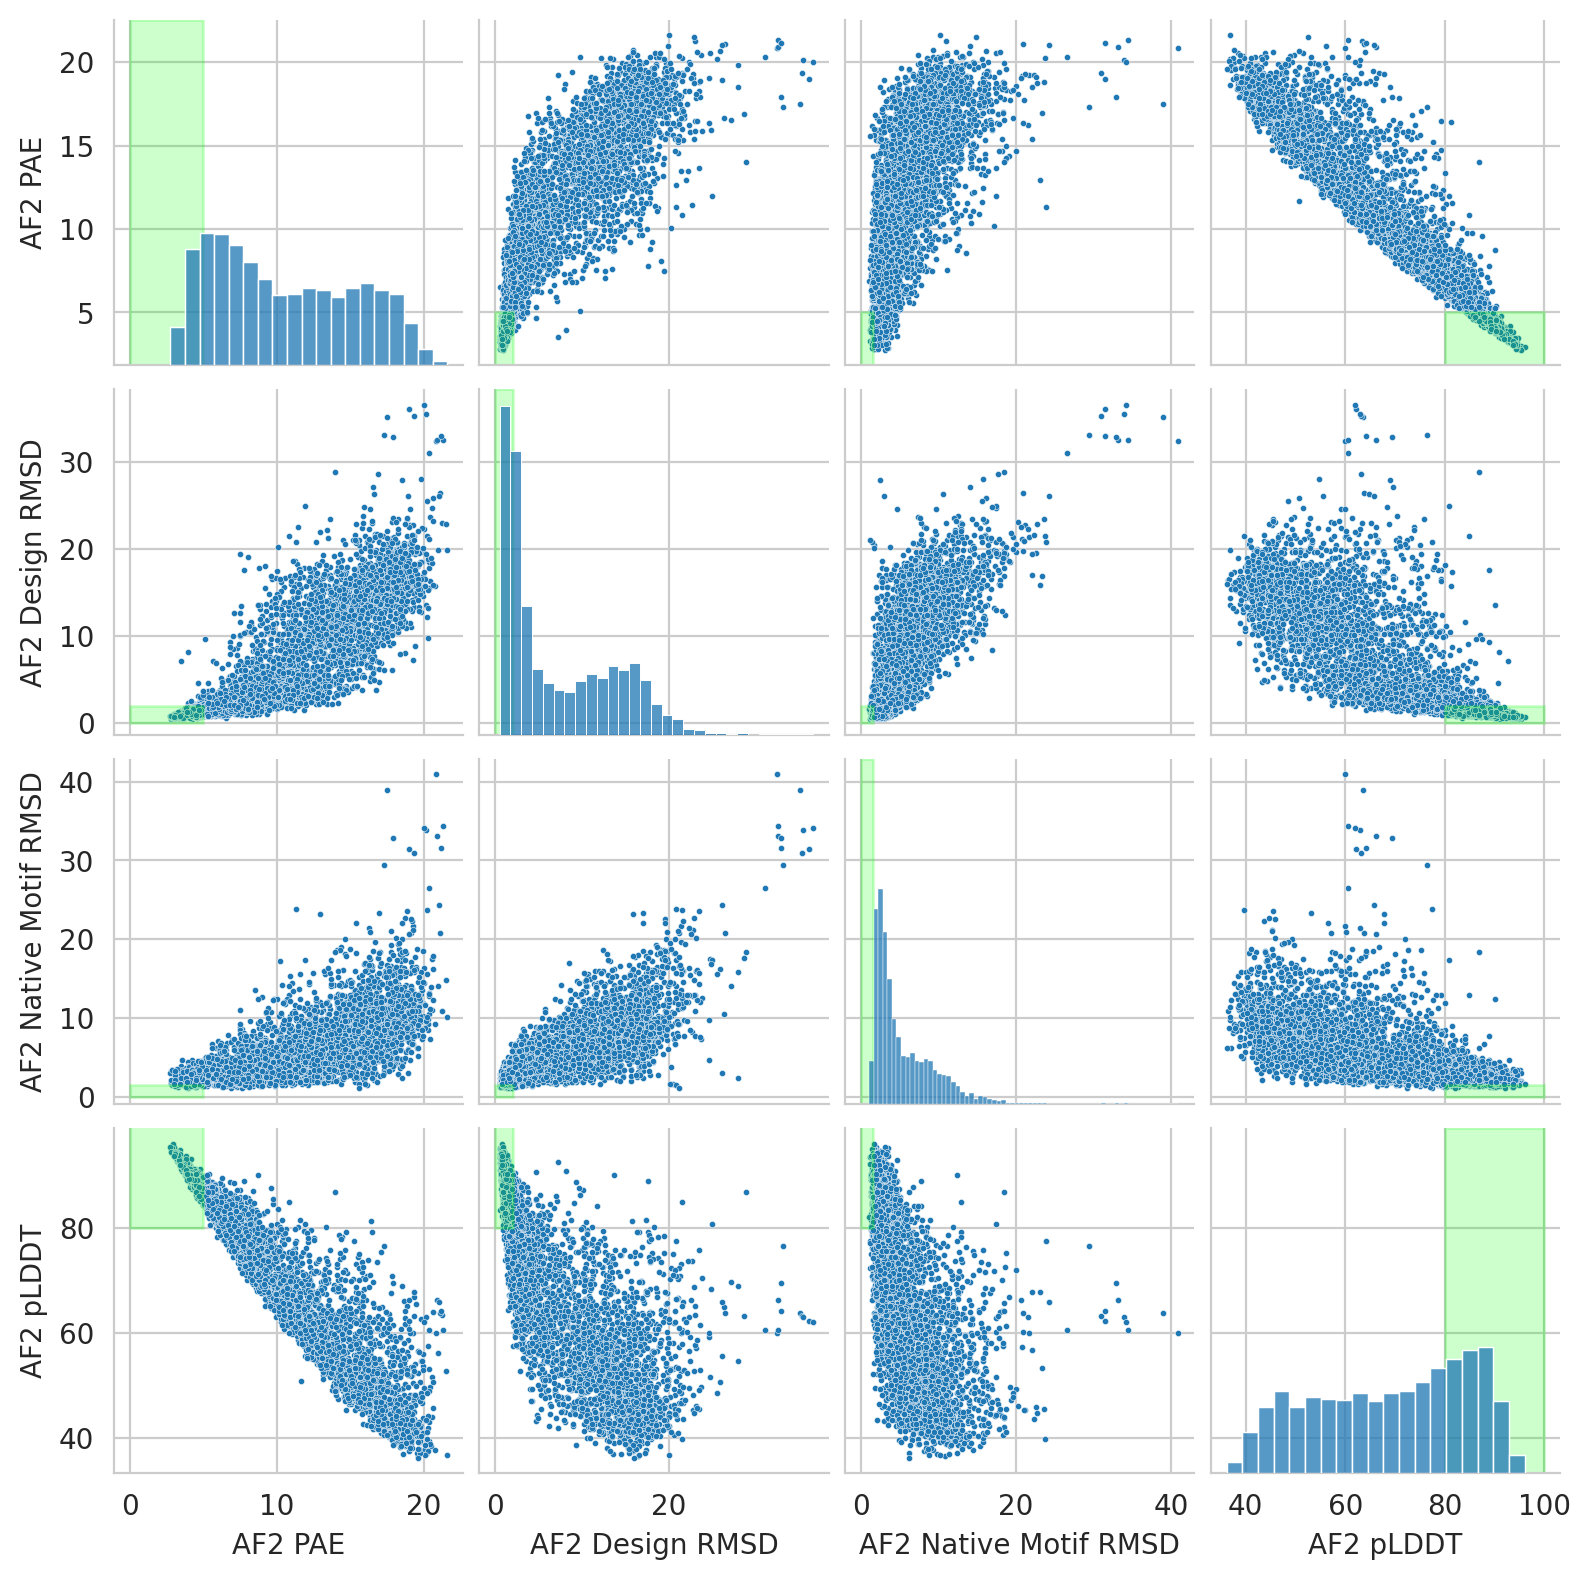

In [17]:
with sns.axes_style('whitegrid'):
    plot_matrix(designs, thresholds, hue=None, height=2)

## Change acceptance thresholds

In [18]:
design_logic.update_acceptance_thresholds(pools=[pool], acceptance_thresholds=thresholds)

In [19]:
db.Design.count(accepted=True, pool_id=pool.id)

26